# Olist Brazilian E-Commerce Operations Analytics

This notebook uses both SQL and Python:

- SQL handles relational joins, order-level aggregation, KPI views, category views, and logistics views.
- Python handles data loading, interactive exploration, visualization, optimization screening, and Monte Carlo simulation.

Run this notebook from the `Brazilian Ecommerce/Notebook` folder or keep the default path logic below.

In [ ]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_DIR = Path.cwd()
if BASE_DIR.name == "Notebook":
    BASE_DIR = BASE_DIR.parent
elif not (BASE_DIR / "olist_orders_dataset.csv").exists():
    BASE_DIR = Path("Brazilian Ecommerce").resolve()

SQL_PATH = BASE_DIR / "SQL" / "01_olist_core_analysis.sql"
OUTPUT_DIR = BASE_DIR / "Outputs"
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"

for path in [CHART_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
N_RUNS = 1000

BASE_DIR

WindowsPath('E:/PROJECT/01_Data_Analytics/Operation Analytics/Brazilian Ecommerce')

## 1. Load CSV tables

The raw Olist data is relational. We load each CSV into pandas first, then register it in an in-memory SQLite database for SQL analysis.

In [ ]:
parse_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders = pd.read_csv(BASE_DIR / "olist_orders_dataset.csv", parse_dates=parse_orders)
items = pd.read_csv(BASE_DIR / "olist_order_items_dataset.csv", parse_dates=["shipping_limit_date"])
payments = pd.read_csv(BASE_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(
    BASE_DIR / "olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"],
)
customers = pd.read_csv(BASE_DIR / "olist_customers_dataset.csv")
sellers = pd.read_csv(BASE_DIR / "olist_sellers_dataset.csv")
products = pd.read_csv(BASE_DIR / "olist_products_dataset.csv")
translation = pd.read_csv(BASE_DIR / "product_category_name_translation.csv")

raw_summary = pd.DataFrame({
    "table": ["orders", "items", "payments", "reviews", "customers", "sellers", "products", "translation"],
    "rows": [len(orders), len(items), len(payments), len(reviews), len(customers), len(sellers), len(products), len(translation)],
    "columns": [orders.shape[1], items.shape[1], payments.shape[1], reviews.shape[1], customers.shape[1], sellers.shape[1], products.shape[1], translation.shape[1]],
})
raw_summary

,table,rows,columns
0,orders,99441,8
1,items,112650,7
2,payments,103886,5
3,reviews,99224,7
4,customers,99441,5
5,sellers,3095,4
6,products,32951,9
7,translation,71,2


## 2. Register data in SQLite and run SQL model

The SQL file creates:

- `df_master`: order-level master table view
- `item_detail`: item-level analytical view
- `yearly_kpis`, `monthly_kpis`
- `category_performance`
- `customer_state_logistics`
- `seller_performance`

In [ ]:
conn = sqlite3.connect(":memory:")

table_map = {
    "orders": orders,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "customers": customers,
    "sellers": sellers,
    "products": products,
    "translation": translation,
}

for table_name, df in table_map.items():
    df.to_sql(table_name, conn, index=False, if_exists="replace")

sql_text = SQL_PATH.read_text(encoding="utf-8")
conn.executescript(sql_text)

pd.read_sql_query("SELECT name, type FROM sqlite_master WHERE type = 'view' ORDER BY name", conn)

,name,type
0,category_performance,view
1,customer_state_logistics,view
2,df_master,view
3,item_detail,view
4,monthly_kpis,view
5,order_item_agg,view
6,payment_agg,view
7,product_dim,view
8,review_agg,view
9,seller_performance,view


## 3. Business health KPIs

Use `payment_value` for realized revenue and `price + freight_value` for item-level GMV diagnostics.

In [ ]:
yearly_kpis = pd.read_sql_query("SELECT * FROM yearly_kpis ORDER BY year", conn)
monthly_kpis = pd.read_sql_query("SELECT * FROM monthly_kpis ORDER BY purchase_month", conn)

yearly_kpis["payment_revenue_yoy"] = yearly_kpis["payment_revenue"].pct_change()
yearly_kpis["delivered_orders_yoy"] = yearly_kpis["delivered_orders"].pct_change()
yearly_kpis["aov_payment_yoy"] = yearly_kpis["aov_payment"].pct_change()

yearly_kpis

,year,delivered_orders,payment_revenue,item_price_revenue,freight_revenue,aov_payment,on_time_rate,late_rate,avg_review_score,avg_delivery_days,payment_revenue_yoy,delivered_orders_yoy,aov_payment_yoy
0,2017,43428,6922900.24,5962902.01,958633.23,159.410985,0.933729,0.066271,4.174346,13.025527,NaN,NaN,NaN
1,2018,52783,8452975.20,7218125.12,1233459.65,160.145789,0.906333,0.093667,4.142036,12.137693,0.221016,0.215414,0.004609


In [ ]:
monthly_kpis.head(), monthly_kpis.tail()

(  purchase_month  delivered_orders  payment_revenue  item_price_revenue  \
 0        2016-09                 1             0.00              134.97   
 1        2016-10               265         46566.71            40325.11   
 2        2016-12                 1            19.62               10.90   
 3        2017-01               750        127545.67           111798.36   
 4        2017-02              1653        271298.65           234223.40   
 
    late_rate  avg_review_score  
 0   1.000000          1.000000  
 1   0.011321          4.011450  
 2   0.000000          5.000000  
 3   0.030667          4.199055  
 4   0.032063          4.202678  ,
    purchase_month  delivered_orders  payment_revenue  item_price_revenue  \
 18        2018-04              6798       1132933.95           973534.09   
 19        2018-05              6749       1128836.69           977544.69   
 20        2018-06              6099       1012090.68           856077.86   
 21        2018-07           

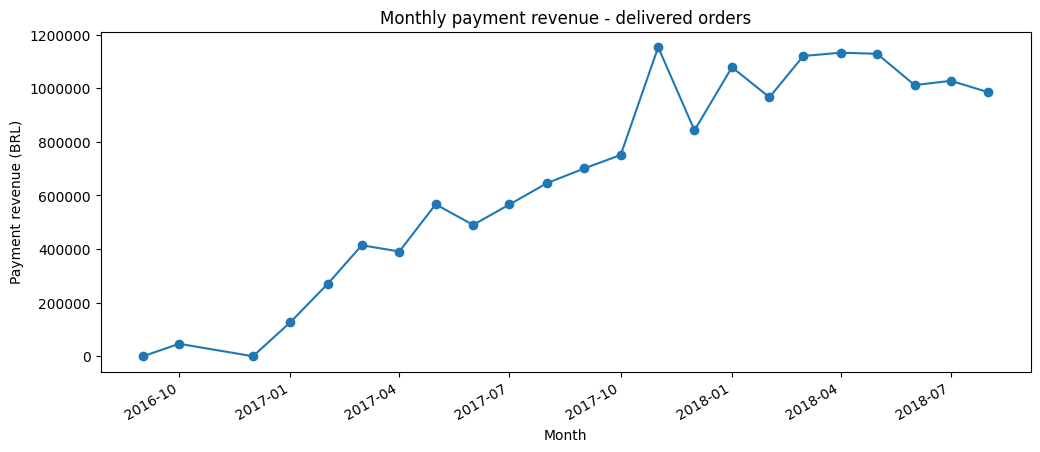

In [ ]:
monthly_plot = monthly_kpis.copy()
monthly_plot["purchase_month_dt"] = pd.to_datetime(monthly_plot["purchase_month"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_plot["purchase_month_dt"], monthly_plot["payment_revenue"], marker="o")
ax.set_title("Monthly payment revenue - delivered orders")
ax.set_xlabel("Month")
ax.set_ylabel("Payment revenue (BRL)")
ax.ticklabel_format(axis="y", style="plain")
fig.autofmt_xdate()
plt.show()

## 4. Category analysis and optimization screen

This is not a full solver yet. It is the first optimization screen from `GEMINI.md`: keep categories with review score >= 3.5 and average freight <= BRL 25, then rank by `revenue x review_score`.

In [ ]:
category = pd.read_sql_query(
    "SELECT * FROM category_performance ORDER BY item_price_revenue DESC",
    conn,
)
category["revenue_share"] = category["item_price_revenue"] / category["item_price_revenue"].sum()
category["cumulative_revenue_share"] = category["revenue_share"].cumsum()

category.head(10)

,product_category_name_english,item_price_revenue,freight_value,orders,items,avg_review_score,late_rate,avg_freight_per_item,aov_item_price,weighted_objective,revenue_share,cumulative_revenue_share
0,health_beauty,1233131.72,178957.81,8647,9465,4.189729,0.090544,18.907323,142.608040,5.166488e+06,0.093267,0.093267
1,watches_gifts,1166176.98,98156.14,5495,5859,4.071711,0.082779,16.753053,212.225110,4.748336e+06,0.088203,0.181470
2,bed_bath_table,1023434.76,201774.50,9272,10953,3.923968,0.083995,18.421848,110.379072,4.015925e+06,0.077407,0.258877
3,sports_leisure,954852.55,163404.36,7530,8431,4.165493,0.074131,19.381374,126.806448,3.977432e+06,0.072220,0.331097
4,computers_accessories,888724.61,143999.16,6530,7644,3.986462,0.077708,18.838195,136.098715,3.542867e+06,0.067218,0.398315
5,furniture_decor,711927.69,168402.23,6307,8160,3.953775,0.084314,20.637528,112.878974,2.814802e+06,0.053846,0.452161
6,housewares,615628.69,142763.56,5743,6795,4.107904,0.064901,21.010090,107.196359,2.528944e+06,0.046563,0.498724
7,cool_stuff,610204.10,81476.79,3559,3718,4.194904,0.067509,21.914145,171.453807,2.559747e+06,0.046152,0.544876
8,auto,578966.65,90488.10,3810,4140,4.116004,0.082850,21.857029,151.959751,2.383029e+06,0.043790,0.588666
9,toys,471286.48,75774.58,3804,4030,4.208927,0.074194,18.802625,123.892345,1.983610e+06,0.035645,0.624312


In [ ]:
category_optimization_top10 = (
    category[
        (category["avg_review_score"] >= 3.5)
        & (category["avg_freight_per_item"] <= 25)
    ]
    .sort_values("weighted_objective", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
category_optimization_top10.insert(0, "selected_rank", np.arange(1, len(category_optimization_top10) + 1))
category_optimization_top10

,selected_rank,product_category_name_english,item_price_revenue,freight_value,orders,items,avg_review_score,late_rate,avg_freight_per_item,aov_item_price,weighted_objective,revenue_share,cumulative_revenue_share
0,1,health_beauty,1233131.72,178957.81,8647,9465,4.189729,0.090544,18.907323,142.608040,5.166488e+06,0.093267,0.093267
1,2,watches_gifts,1166176.98,98156.14,5495,5859,4.071711,0.082779,16.753053,212.225110,4.748336e+06,0.088203,0.181470
2,3,bed_bath_table,1023434.76,201774.50,9272,10953,3.923968,0.083995,18.421848,110.379072,4.015925e+06,0.077407,0.258877
3,4,sports_leisure,954852.55,163404.36,7530,8431,4.165493,0.074131,19.381374,126.806448,3.977432e+06,0.072220,0.331097
4,5,computers_accessories,888724.61,143999.16,6530,7644,3.986462,0.077708,18.838195,136.098715,3.542867e+06,0.067218,0.398315
5,6,furniture_decor,711927.69,168402.23,6307,8160,3.953775,0.084314,20.637528,112.878974,2.814802e+06,0.053846,0.452161
6,7,cool_stuff,610204.10,81476.79,3559,3718,4.194904,0.067509,21.914145,171.453807,2.559747e+06,0.046152,0.544876
7,8,housewares,615628.69,142763.56,5743,6795,4.107904,0.064901,21.010090,107.196359,2.528944e+06,0.046563,0.498724
8,9,auto,578966.65,90488.10,3810,4140,4.116004,0.082850,21.857029,151.959751,2.383029e+06,0.043790,0.588666
9,10,toys,471286.48,75774.58,3804,4030,4.208927,0.074194,18.802625,123.892345,1.983610e+06,0.035645,0.624312


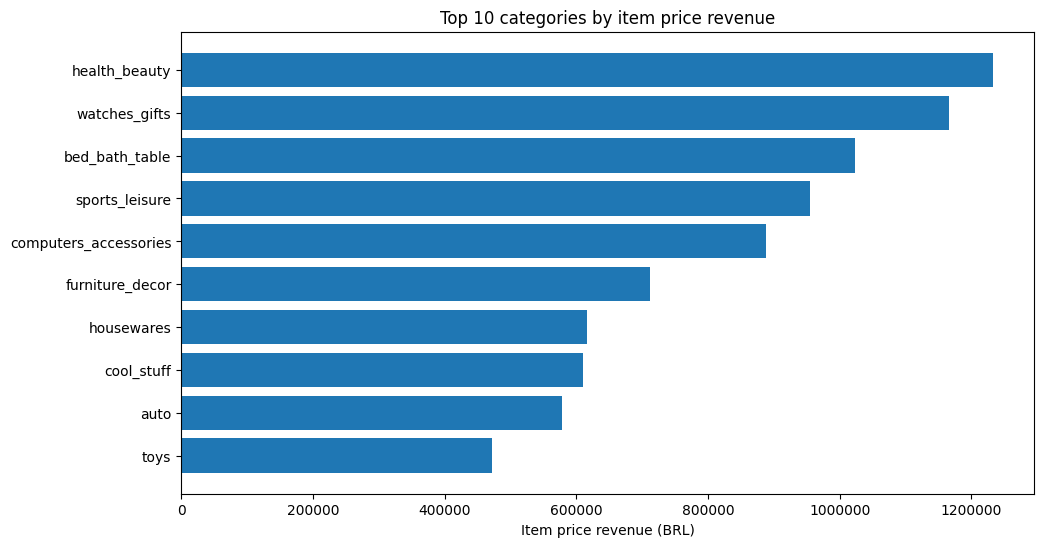

In [ ]:
top_cat = category.head(10).sort_values("item_price_revenue")

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_cat["product_category_name_english"], top_cat["item_price_revenue"])
ax.set_title("Top 10 categories by item price revenue")
ax.set_xlabel("Item price revenue (BRL)")
ax.ticklabel_format(axis="x", style="plain")
plt.show()

## 5. Logistics analysis

In [ ]:
customer_state_logistics = pd.read_sql_query(
    "SELECT * FROM customer_state_logistics ORDER BY late_rate DESC, orders DESC",
    conn,
)
seller_performance = pd.read_sql_query(
    "SELECT * FROM seller_performance ORDER BY item_price_revenue DESC",
    conn,
)

customer_state_logistics.head(10)

,customer_state,orders,payment_revenue,avg_delivery_days,late_rate,avg_freight,avg_review_score
0,AL,397,94195.79,24.543855,0.239295,38.581285,3.852792
1,MA,717,147807.29,21.572976,0.196653,42.948633,3.833567
2,PI,476,105272.17,19.457098,0.159664,42.977290,3.993631
3,CE,1279,266463.97,21.266579,0.153245,36.496787,3.941870
4,SE,335,70289.13,21.519788,0.152239,40.940119,3.907186
5,BA,3256,591270.60,19.335466,0.140356,29.961201,3.930009
6,RJ,12350,2055690.45,15.309438,0.134737,23.947404,3.965141
7,TO,274,60007.37,17.658063,0.127737,42.353504,4.153846
8,PA,946,212027.55,23.772917,0.123679,39.696596,3.909968
9,ES,1995,317682.65,15.789307,0.122306,24.568662,4.079736


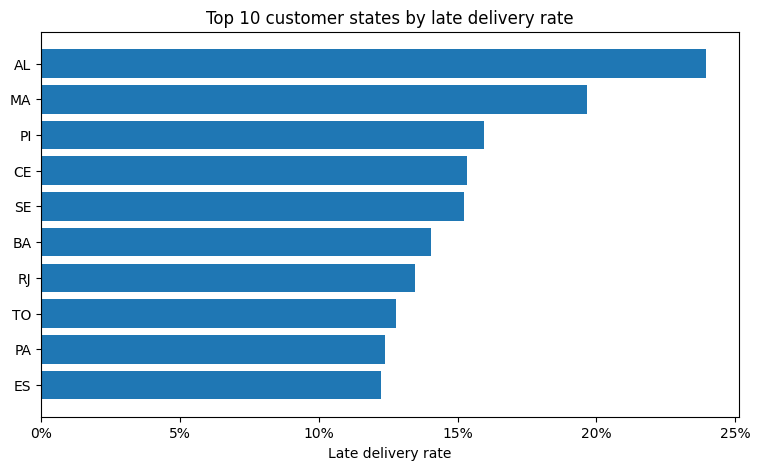

In [ ]:
top_state = customer_state_logistics.head(10).sort_values("late_rate")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_state["customer_state"], top_state["late_rate"])
ax.set_title("Top 10 customer states by late delivery rate")
ax.set_xlabel("Late delivery rate")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.show()

## 6. Monte Carlo simulation

Simulation is done in Python because it is more natural for random sampling and risk metrics.

In [ ]:
item_detail = pd.read_sql_query("SELECT * FROM item_detail WHERE delivered_flag = 1", conn)
top_categories = (
    item_detail.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

monthly_cat = (
    item_detail[item_detail["product_category_name_english"].isin(top_categories)]
    .groupby(["purchase_month", "product_category_name_english"], as_index=False)["price"]
    .sum()
)

revenue_stats = (
    monthly_cat.groupby("product_category_name_english", as_index=False)
    .agg(mu_monthly_revenue=("price", "mean"), sigma_monthly_revenue=("price", "std"))
    .fillna({"sigma_monthly_revenue": 0})
)

rng = np.random.default_rng(RANDOM_SEED)
draws = [
    np.clip(rng.normal(row.mu_monthly_revenue, row.sigma_monthly_revenue, N_RUNS), 0, None)
    for row in revenue_stats.itertuples(index=False)
]
total_revenue = np.vstack(draws).sum(axis=0)

revenue_simulation_summary = pd.DataFrame({
    "scenario": ["top_5_category_monthly_revenue"],
    "n_runs": [N_RUNS],
    "expected_revenue": [total_revenue.mean()],
    "stddev_revenue": [total_revenue.std(ddof=1)],
    "p_revenue_below_80pct_mean": [(total_revenue < 0.8 * total_revenue.mean()).mean()],
    "percentile_5": [np.percentile(total_revenue, 5)],
    "percentile_95": [np.percentile(total_revenue, 95)],
})

revenue_simulation_summary

,scenario,n_runs,expected_revenue,stddev_revenue,p_revenue_below_80pct_mean,percentile_5,percentile_95
0,top_5_category_monthly_revenue,1000,248589.034986,62896.557099,0.214,146069.353873,355696.236722


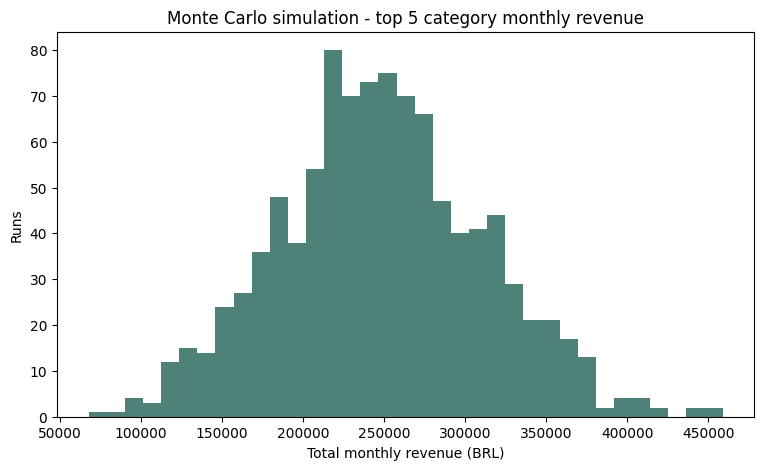

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(total_revenue, bins=35, color="#2F6B5F", alpha=0.85)
ax.set_title("Monte Carlo simulation - top 5 category monthly revenue")
ax.set_xlabel("Total monthly revenue (BRL)")
ax.set_ylabel("Runs")
ax.ticklabel_format(axis="x", style="plain")
plt.show()

## 7. Export key notebook tables

In [ ]:
exports = {
    "notebook_yearly_kpis.csv": yearly_kpis,
    "notebook_monthly_kpis.csv": monthly_kpis,
    "notebook_category_optimization_top10.csv": category_optimization_top10,
    "notebook_customer_state_logistics.csv": customer_state_logistics,
    "notebook_revenue_simulation_summary.csv": revenue_simulation_summary,
}

for filename, df in exports.items():
    df.to_csv(TABLE_DIR / filename, index=False, encoding="utf-8-sig")

sorted(exports)

['notebook_category_optimization_top10.csv',
 'notebook_customer_state_logistics.csv',
 'notebook_monthly_kpis.csv',
 'notebook_revenue_simulation_summary.csv',
 'notebook_yearly_kpis.csv']